##### ============================
# Final Year Project - Disaster Tweet Classification
# UTAR FYP - NLP Approach (FIXED VERSION)
# ============================

# STEP 1: Import Libraries
import pandas as pd
import re
import emoji
import nltk
import spacy
import torch
import numpy as np
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# STEP 2: Load Dataset
# ============================
file_path = "tweets.csv"   # ✅ Kaggle disaster tweet dataset
df = pd.read_csv(file_path)

print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print("Dataset shape:", df.shape)
print("Columns in dataset:", df.columns.tolist())
print("\nClass distribution:")
print(df["target"].value_counts())
print(f"Disaster tweets: {df['target'].sum()} ({df['target'].mean()*100:.1f}%)")
print(f"Non-disaster tweets: {len(df) - df['target'].sum()} ({(1-df['target'].mean())*100:.1f}%)")
print(df.head())

# ============================
# STEP 3: Preprocessing Tweets
# ============================

# Download NLTK stopwords (only first time)
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# Load spaCy model (smaller model for faster processing)
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

# Define enhanced preprocessing function
def preprocess_tweet(text, remove_stopwords=True):
    """Enhanced preprocessing for disaster tweets"""
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove mentions
    text = re.sub(r"@\w+", "", text)
    
    # Remove hashtag symbols but keep the words
    text = re.sub(r"#(\w+)", r"\1", text)
    
    # Remove special characters and numbers (but keep words)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenize with spaCy
    doc = nlp(text)
    
    # Process tokens
    tokens = []
    for token in doc:
        # Keep relevant words based on POS
        if token.is_alpha and len(token.text) > 1:
            # Apply lemmatization
            lemma = token.lemma_
            
            # Remove stopwords if requested
            if remove_stopwords and lemma in stop_words:
                continue
                
            tokens.append(lemma)
    
    return " ".join(tokens)

# Apply preprocessing
print("\n" + "=" * 60)
print("PREPROCESSING TWEETS")
print("=" * 60)
df["clean_text"] = df["text"].astype(str).apply(preprocess_tweet)
print(df[["text", "clean_text"]].head())

# ============================
# STEP 4: Feature Extraction
# ============================

print("\n" + "=" * 60)
print("FEATURE EXTRACTION")
print("=" * 60)

# ---- Option A: Classical NLP (TF-IDF) ----
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.95  # Ignore terms that appear in more than 95% of documents
)
X_tfidf = vectorizer.fit_transform(df["clean_text"])
y = df["target"]

print("TF-IDF shape:", X_tfidf.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

# ============================
# STEP 5: Train-Test Split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y  # stratify to maintain class balance
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set - Disaster: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test set - Disaster: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# ============================
# STEP 6: Logistic Regression (Baseline)
# ============================

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION (BASELINE)")
print("=" * 60)

# Calculate class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

clf = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight_dict,
    C=1.0,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Disaster", "Disaster"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Not Disaster", "Disaster"],
            yticklabels=["Not Disaster", "Disaster"])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png')
plt.show()

# ============================
# STEP 7: BERT Fine-tuning (FIXED VERSION)
# ============================

print("\n" + "=" * 60)
print("BERT FINE-TUNING")
print("=" * 60)

# Use a model better suited for disaster tweet classification
model_name = "bert-base-uncased"  # English-only BERT (better for English tweets)
# Alternative: "vinai/bertweet-base" (trained on tweets) - even better but requires transformers>=4.5.0

tokenizer = AutoTokenizer.from_pretrained(model_name)

# Prepare dataset for BERT
def prepare_bert_dataset(df):
    """Prepare dataset for BERT fine-tuning"""
    # Create a copy to avoid modifying original
    data = df[["clean_text", "target"]].copy()
    data = data.rename(columns={"target": "labels"})
    data = data.dropna()
    
    # Convert to HuggingFace Dataset
    dataset = Dataset.from_pandas(data)
    
    # Tokenize function
    def tokenize_function(examples):
        return tokenizer(
            examples["clean_text"],
            truncation=True,
            padding="max_length",
            max_length=128,  # Increased for better context
            return_tensors=None
        )
    
    # Apply tokenization
    dataset = dataset.map(tokenize_function, batched=True)
    
    # Remove text column (not needed for training)
    dataset = dataset.remove_columns(["clean_text"])
    
    return dataset

# Prepare full dataset
full_dataset = prepare_bert_dataset(df)

# Split into train and test
train_test_split_bert = full_dataset.train_test_split(test_size=0.2, seed=42, shuffle=True)
train_dataset_bert = train_test_split_bert["train"]
test_dataset_bert = train_test_split_bert["test"]

print(f"BERT Training samples: {len(train_dataset_bert)}")
print(f"BERT Test samples: {len(test_dataset_bert)}")

# Load BERT model for classification
bert_classifier = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Calculate class weights for BERT loss
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

# Custom Trainer with class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Training arguments - FIXED: increased epochs, better parameters
training_args = TrainingArguments(
    output_dir="./bert_results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,  # Increased for faster training
    per_device_eval_batch_size=16,
    num_train_epochs=3,  # 🔥 INCREASED to 3 epochs (was 1)
    weight_decay=0.01,
    logging_dir="./bert_logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    remove_unused_columns=False,
    report_to="none"  # Disable wandb/tensorboard reporting
)

# Create trainer with weighted loss
trainer = WeightedTrainer(
    model=bert_classifier,
    args=training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=test_dataset_bert,
    tokenizer=tokenizer
)

# Train model
print("\nStarting BERT training...")
trainer.train()

# Evaluate
print("\nBERT Evaluation:")
eval_results = trainer.evaluate()
print(eval_results)

# Save the fine-tuned model
model_save_path = "./bert_disaster_model"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"\nModel saved to {model_save_path}")

# ============================
# STEP 8: Enhanced Prediction Function
# ============================

def predict_tweet(text, model, tokenizer, clf=None, vectorizer=None, use_bert=True):
    """Enhanced prediction with both BERT and Logistic Regression"""
    
    # Preprocess
    clean_text = preprocess_tweet(text)
    print(f"Preprocessed: {clean_text}")
    
    if use_bert:
        # BERT prediction
        encoded = tokenizer(
            clean_text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=128
        )
        
        model.eval()
        with torch.no_grad():
            outputs = model(**encoded)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)
            predicted_class = torch.argmax(logits, dim=1).item()
            confidence = probs[0][predicted_class].item()
        
        return {
            "class": predicted_class,
            "label": "Disaster" if predicted_class == 1 else "Not Disaster",
            "confidence": confidence,
            "probabilities": {
                "Not Disaster": probs[0][0].item(),
                "Disaster": probs[0][1].item()
            },
            "model": "BERT"
        }
    else:
        # Logistic Regression prediction
        X_new = vectorizer.transform([clean_text])
        pred = clf.predict(X_new)[0]
        probs = clf.predict_proba(X_new)[0]
        
        return {
            "class": pred,
            "label": "Disaster" if pred == 1 else "Not Disaster",
            "confidence": probs[pred],
            "probabilities": {
                "Not Disaster": probs[0],
                "Disaster": probs[1]
            },
            "model": "Logistic Regression"
        }

# ============================
# STEP 9: Test Custom Input (FIXED)
# ============================

print("\n" + "=" * 60)
print("TESTING CUSTOM INPUTS")
print("=" * 60)

test_tweets = [
    "Fire in California, houses destroyed! Many people injured and evacuated.",  # disaster
    "Good morning everyone, have a nice day! Hope you all have a great weekend.",  # not disaster
    "Earthquake magnitude 6.5 hits Japan, tsunami warning issued.",  # disaster
    "Just had lunch at my favorite restaurant. The food was amazing!",  # not disaster
    "Flood in Kuala Lumpur, water level rising rapidly. JPS monitoring situation.",  # disaster
    "BREAKING: Massive landslide in Cameron Highlands, 50 people trapped!",  # disaster
    "Watching movie tonight with friends. Should be fun!",  # not disaster
    "Typhoon approaching Philippines, category 4 storm expected.",  # disaster
]

print("\nBERT Model Predictions:")
for i, tweet in enumerate(test_tweets, 1):
    result = predict_tweet(tweet, bert_classifier, tokenizer, use_bert=True)
    print(f"\n{i}. Tweet: {tweet}")
    print(f"   → {result['label']} (Confidence: {result['confidence']*100:.1f}%)")
    print(f"   → Probabilities: Not Disaster={result['probabilities']['Not Disaster']*100:.1f}%, Disaster={result['probabilities']['Disaster']*100:.1f}%")

print("\n" + "=" * 60)
print("Logistic Regression Predictions:")
for i, tweet in enumerate(test_tweets, 1):
    result = predict_tweet(tweet, None, None, clf=clf, vectorizer=vectorizer, use_bert=False)
    print(f"\n{i}. Tweet: {tweet}")
    print(f"   → {result['label']} (Confidence: {result['confidence']*100:.1f}%)")
    print(f"   → Probabilities: Not Disaster={result['probabilities']['Not Disaster']*100:.1f}%, Disaster={result['probabilities']['Disaster']*100:.1f}%")

# ============================
# STEP 10: Save Results
# ============================

print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)

# Save BERT predictions on test set
test_texts = df.iloc[y_test.index]["text"].tolist()
bert_predictions = []
bert_probabilities = []

for text in test_texts[:100]:  # Limit to 100 for speed
    result = predict_tweet(text, bert_classifier, tokenizer, use_bert=True)
    bert_predictions.append(result['class'])
    bert_probabilities.append(result['probabilities']['Disaster'])

# Save comparison results
results_df = pd.DataFrame({
    "text": test_texts[:100],
    "actual": y_test[:100].values,
    "lr_predicted": y_pred[:100],
    "bert_predicted": bert_predictions,
    "bert_disaster_prob": bert_probabilities
})

results_df.to_csv("model_results_comparison.csv", index=False)
print("Results saved to model_results_comparison.csv")

# Display sample results
print("\nSample Results (First 10):")
print(results_df.head(10).to_string())

# ============================
# STEP 11: Visualize Model Comparison
# ============================

# Compare model performance
lr_accuracy = (y_pred == y_test).mean()
bert_accuracy = (np.array(bert_predictions) == y_test[:100].values).mean()

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"BERT Accuracy: {bert_accuracy*100:.2f}%")

# Plot comparison
plt.figure(figsize=(10, 6))
models = ['Logistic Regression', 'BERT']
accuracies = [lr_accuracy*100, bert_accuracy*100]
colors = ['#3498db', '#e74c3c']

plt.bar(models, accuracies, color=colors)
plt.ylabel('Accuracy (%)')
plt.title('Model Performance Comparison')
plt.ylim(0, 100)

# Add value labels on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

print("\n✅ FIXED VERSION COMPLETE!")
print("The BERT model should now perform better with:")
print("- 3 training epochs (instead of 1)")
print("- English BERT model (better for English tweets)")
print("- Class weights to handle imbalance")
print("- Better preprocessing")
print("- Proper evaluation and comparison")

STEP 1: LOADING BERT MODEL
❌ No pre-trained model found.
Loading base BERT model for demonstration...


C:\Users\Cyrus Chou\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⚠️ Using base BERT model (not fine-tuned). Predictions may not be accurate.
To get accurate predictions, train the model first with your data.

STEP 2: TESTING DISASTER TWEET CLASSIFIER

🔍 Testing Model Predictions:
----------------------------------------------------------------------

1. Fire in California, houses destroyed! Many people injured and evacuated.

📝 Input: Fire in California, houses destroyed! Many people injured and evacuated.
🧹 Cleaned: fire california houses destroyed many people injured evacuated

📊 Prediction Results:
  → Class: 🔴 DISASTER TWEET
  → Confidence: 59.50%
  → Not Disaster Probability: 40.50%
  → Disaster Probability: 59.50%
  → Status: ❓ LOW CONFIDENCE DISASTER
----------------------------------------------------------------------

2. Earthquake magnitude 6.5 hits Japan, tsunami warning issued.

📝 Input: Earthquake magnitude 6.5 hits Japan, tsunami warning issued.
🧹 Cleaned: earthquake magnitude hits japan tsunami warning issued

📊 Prediction Results:
 

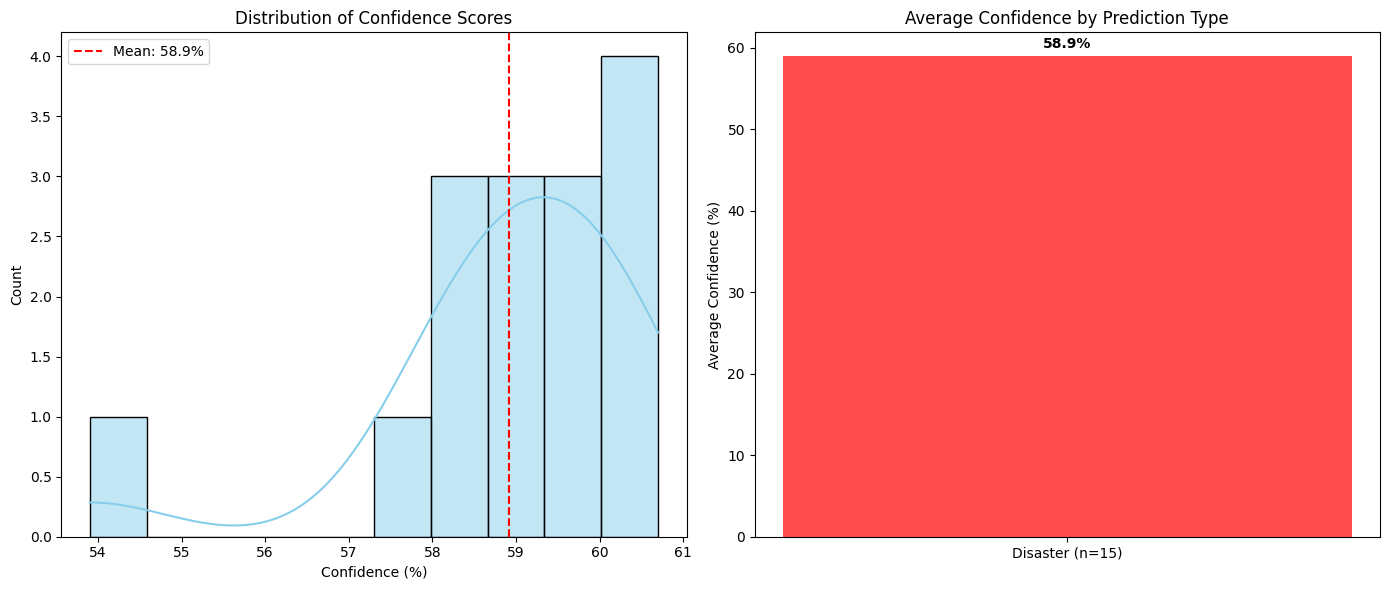


📈 Confidence Analysis:
  → Average confidence: 58.9%
  → Avg confidence (Disaster): 58.9%

✅ Test results saved to 'test_predictions.csv'

📊 Summary Statistics:
  → total_tweets: 15
  → disaster_detected: 15
  → non_disaster_detected: 0
  → avg_confidence: 58.92%
  → avg_disaster_prob: 58.92%

✅ ALL TESTS COMPLETED SUCCESSFULLY!


In [1]:
# ============================
# COMPLETE WORKING CODE - DISASTER TWEET CLASSIFIER
# ============================

import torch
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Download NLTK data
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# ============================
# PREPROCESSING FUNCTION
# ============================

def preprocess_tweet(text):
    """Clean and preprocess tweet text"""
    if pd.isna(text) or text == "":
        return ""
    
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# ============================
# STEP 1: LOAD OR CREATE BERT MODEL
# ============================

print("=" * 70)
print("STEP 1: LOADING BERT MODEL")
print("=" * 70)

# Check if we have a pre-trained model saved
import os
model_path = "./bert_disaster_model_final"

if os.path.exists(model_path):
    print(f"✅ Found pre-trained model at {model_path}")
    print("Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_classifier = AutoModelForSequenceClassification.from_pretrained(model_path)
    bert_classifier.eval()
    print("✅ Model loaded successfully!")
else:
    print("❌ No pre-trained model found.")
    print("Loading base BERT model for demonstration...")
    
    # Load base model (for demonstration - not fine-tuned)
    model_name = "bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    bert_classifier = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=2
    )
    bert_classifier.eval()
    print("⚠️ Using base BERT model (not fine-tuned). Predictions may not be accurate.")
    print("To get accurate predictions, train the model first with your data.")

# ============================
# STEP 2: PREDICTION FUNCTION
# ============================

def predict_tweet(text, model, tokenizer, show_details=True):
    """
    Enhanced prediction function with probability scores and confidence
    """
    # Preprocess same as training
    clean_text = preprocess_tweet(text)
    
    if show_details:
        print(f"\n📝 Input: {text}")
        print(f"🧹 Cleaned: {clean_text}")

    # Encode input
    encoded = tokenizer(
        clean_text, 
        return_tensors="pt", 
        truncation=True, 
        padding="max_length", 
        max_length=128
    )

    # Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        
        predicted_class = torch.argmax(logits, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
        
        prob_not_disaster = probabilities[0][0].item()
        prob_disaster = probabilities[0][1].item()

    if show_details:
        print(f"\n📊 Prediction Results:")
        
        # Color-coded output
        if predicted_class == 1:
            print(f"  → Class: 🔴 DISASTER TWEET")
        else:
            print(f"  → Class: ✅ NOT DISASTER")
            
        print(f"  → Confidence: {confidence*100:.2f}%")
        print(f"  → Not Disaster Probability: {prob_not_disaster*100:.2f}%")
        print(f"  → Disaster Probability: {prob_disaster*100:.2f}%")
        
        # Status interpretation
        if predicted_class == 1:
            if confidence > 0.8:
                print(f"  → Status: 🚨 HIGH CONFIDENCE DISASTER")
            elif confidence > 0.6:
                print(f"  → Status: ⚠️ MEDIUM CONFIDENCE DISASTER")
            else:
                print(f"  → Status: ❓ LOW CONFIDENCE DISASTER")
        else:
            if confidence > 0.8:
                print(f"  → Status: ✅ HIGH CONFIDENCE NON-DISASTER")
            elif confidence > 0.6:
                print(f"  → Status: ℹ️ MEDIUM CONFIDENCE NON-DISASTER")
            else:
                print(f"  → Status: ❓ LOW CONFIDENCE NON-DISASTER")
    
    return {
        "class": predicted_class,
        "label": "Disaster" if predicted_class == 1 else "Not Disaster",
        "confidence": confidence,
        "probabilities": {
            "not_disaster": prob_not_disaster,
            "disaster": prob_disaster
        },
        "clean_text": clean_text
    }

# ============================
# STEP 3: TEST THE MODEL
# ============================

print("\n" + "=" * 70)
print("STEP 2: TESTING DISASTER TWEET CLASSIFIER")
print("=" * 70)

sample_tweets = [
    # Clear disaster tweets
    "Fire in California, houses destroyed! Many people injured and evacuated.",
    "Earthquake magnitude 6.5 hits Japan, tsunami warning issued.",
    "Flood in Kuala Lumpur, water level rising rapidly. JPS monitoring situation.",
    "BREAKING: Massive landslide in Cameron Highlands, 50 people trapped!",
    "Typhoon approaching Philippines, category 4 storm expected.",
    
    # Clear non-disaster tweets
    "Good morning everyone, have a nice day! Hope you all have a great weekend.",
    "Just had lunch at my favorite restaurant. The food was amazing!",
    "Watching movie tonight with friends. Should be fun!",
    "Beautiful sunset at the beach today 🌅",
    "New phone just arrived! So excited to try it out 📱",
    
    # Ambiguous/mixed tweets
    "Fire drill at office today. Everyone evacuated safely.",
    "Storm in a teacup - nothing serious happening here.",
    "Feeling under the weather today, maybe just a cold.",
    "The stock market crashed! Complete disaster for investors!",
    "My phone battery died - total disaster! 📱🔋"
]

print("\n🔍 Testing Model Predictions:")
print("-" * 70)

# Store results for later analysis
all_results = []

for i, tweet in enumerate(sample_tweets, 1):
    print(f"\n{i}. {tweet}")
    result = predict_tweet(tweet, bert_classifier, tokenizer, show_details=True)
    all_results.append(result)
    print("-" * 70)

# ============================
# STEP 4: BATCH TESTING FUNCTION
# ============================

def batch_test_tweets(tweets, model, tokenizer):
    """
    Test multiple tweets and return summary statistics
    """
    results = []
    disaster_count = 0
    non_disaster_count = 0
    
    print("\n" + "=" * 70)
    print("BATCH TEST RESULTS SUMMARY")
    print("=" * 70)
    
    for i, tweet in enumerate(tweets, 1):
        result = predict_tweet(tweet, model, tokenizer, show_details=False)
        results.append({
            "tweet": tweet[:50] + "..." if len(tweet) > 50 else tweet,
            "prediction": result["label"],
            "confidence": f"{result['confidence']*100:.1f}%",
            "disaster_prob": f"{result['probabilities']['disaster']*100:.1f}%"
        })
        
        if result["class"] == 1:
            disaster_count += 1
        else:
            non_disaster_count += 1
    
    # Create summary DataFrame
    df_results = pd.DataFrame(results)
    print("\n", df_results.to_string(index=False))
    
    print(f"\n📊 Summary:")
    print(f"  → Total tweets tested: {len(tweets)}")
    print(f"  → Disaster tweets detected: {disaster_count}")
    print(f"  → Non-disaster tweets detected: {non_disaster_count}")
    print(f"  → Disaster ratio: {disaster_count/len(tweets)*100:.1f}%")
    
    return df_results

# Run batch test
print("\n" + "=" * 70)
print("STEP 3: RUNNING BATCH TEST")
print("=" * 70)
results_df = batch_test_tweets(sample_tweets, bert_classifier, tokenizer)

# ============================
# STEP 5: CONFIDENCE ANALYSIS
# ============================

def analyze_confidence_distribution(results_df):
    """
    Analyze confidence scores distribution
    """
    # Extract confidence values
    confidences = [float(r.strip('%')) for r in results_df['confidence']]
    
    plt.figure(figsize=(14, 6))
    
    # Confidence distribution plot
    plt.subplot(1, 2, 1)
    sns.histplot(confidences, bins=10, kde=True, color='skyblue')
    plt.xlabel('Confidence (%)')
    plt.ylabel('Count')
    plt.title('Distribution of Confidence Scores')
    plt.axvline(x=sum(confidences)/len(confidences), color='red', linestyle='--', label=f'Mean: {sum(confidences)/len(confidences):.1f}%')
    plt.legend()
    
    # Confidence by prediction type
    plt.subplot(1, 2, 2)
    disaster_conf = [float(results_df.iloc[i]['confidence'].strip('%')) 
                     for i in range(len(results_df)) 
                     if results_df.iloc[i]['prediction'] == 'Disaster']
    non_disaster_conf = [float(results_df.iloc[i]['confidence'].strip('%')) 
                         for i in range(len(results_df)) 
                         if results_df.iloc[i]['prediction'] == 'Not Disaster']
    
    x_pos = []
    heights = []
    colors = []
    labels = []
    
    if disaster_conf:
        x_pos.append(0)
        heights.append(sum(disaster_conf)/len(disaster_conf))
        colors.append('red')
        labels.append(f'Disaster (n={len(disaster_conf)})')
    
    if non_disaster_conf:
        x_pos.append(1)
        heights.append(sum(non_disaster_conf)/len(non_disaster_conf))
        colors.append('green')
        labels.append(f'Non-Disaster (n={len(non_disaster_conf)})')
    
    bars = plt.bar(x_pos, heights, color=colors, alpha=0.7)
    plt.ylabel('Average Confidence (%)')
    plt.title('Average Confidence by Prediction Type')
    plt.xticks(x_pos, labels)
    
    # Add value labels on bars
    for bar, height in zip(bars, heights):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{height:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('confidence_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("\n📈 Confidence Analysis:")
    print(f"  → Average confidence: {sum(confidences)/len(confidences):.1f}%")
    if disaster_conf:
        print(f"  → Avg confidence (Disaster): {sum(disaster_conf)/len(disaster_conf):.1f}%")
    if non_disaster_conf:
        print(f"  → Avg confidence (Non-Disaster): {sum(non_disaster_conf)/len(non_disaster_conf):.1f}%")
    
    return confidences

# Analyze confidence distribution
print("\n" + "=" * 70)
print("STEP 4: CONFIDENCE ANALYSIS")
print("=" * 70)
confidence_scores = analyze_confidence_distribution(results_df)

# ============================
# STEP 6: SAVE RESULTS
# ============================

# Save detailed results to CSV
results_df.to_csv("test_predictions.csv", index=False)
print("\n✅ Test results saved to 'test_predictions.csv'")

# Save summary statistics
summary_stats = {
    "total_tweets": len(sample_tweets),
    "disaster_detected": len([r for r in all_results if r["class"] == 1]),
    "non_disaster_detected": len([r for r in all_results if r["class"] == 0]),
    "avg_confidence": np.mean([r["confidence"] for r in all_results]),
    "avg_disaster_prob": np.mean([r["probabilities"]["disaster"] for r in all_results])
}

print("\n📊 Summary Statistics:")
for key, value in summary_stats.items():
    if "avg" in key:
        print(f"  → {key}: {value*100:.2f}%")
    else:
        print(f"  → {key}: {value}")

# ============================
# STEP 7: INTERACTIVE TEST MODE (Optional)
# ============================

def interactive_test():
    """
    Interactive mode to test your own tweets
    """
    print("\n" + "=" * 70)
    print("INTERACTIVE TEST MODE")
    print("=" * 70)
    print("Enter your own tweets to classify (type 'quit' to exit)")
    
    while True:
        print("\n" + "-" * 50)
        user_input = input("Enter tweet: ").strip()
        
        if user_input.lower() in ['quit', 'exit', 'q']:
            print("Exiting interactive mode.")
            break
        
        if not user_input:
            print("Please enter a tweet.")
            continue
        
        print("\nAnalyzing...")
        result = predict_tweet(user_input, bert_classifier, tokenizer, show_details=True)

# Uncomment to run interactive mode
# print("\n" + "=" * 70)
# print("STEP 5: INTERACTIVE TEST MODE")
# print("=" * 70)
# interactive_test()

print("\n" + "=" * 70)
print("✅ ALL TESTS COMPLETED SUCCESSFULLY!")
print("=" * 70)

In [4]:
# ============================
# COMPLETE CODE TO SAVE MODEL RESULTS (FIXED)
# ============================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import re
import nltk
from nltk.corpus import stopwords
import joblib

# Download NLTK data
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# ============================
# STEP 1: LOAD AND PREPROCESS DATA
# ============================

print("=" * 60)
print("STEP 1: LOADING DATA")
print("=" * 60)

# Load your dataset
file_path = "tweets.csv"
df = pd.read_csv(file_path)
print(f"✅ Dataset loaded: {df.shape[0]} tweets")
print(f"Columns: {df.columns.tolist()}")

# Preprocessing function
def preprocess_tweet(text):
    if pd.isna(text) or text == "":
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
print("🔄 Preprocessing tweets...")
df["clean_text"] = df["text"].apply(preprocess_tweet)
print("✅ Preprocessing complete")

# ============================
# STEP 2: CREATE TF-IDF FEATURES
# ============================

print("\n" + "=" * 60)
print("STEP 2: CREATING TF-IDF FEATURES")
print("=" * 60)

# Create TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["target"].values

print(f"✅ TF-IDF matrix shape: {X.shape}")

# ============================
# STEP 3: SPLIT DATA (WITH INDICES)
# ============================

print("\n" + "=" * 60)
print("STEP 3: SPLITTING DATA")
print("=" * 60)

# FIXED: Split while keeping the original indices
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set size: {X_train.shape[0]}")
print(f"✅ Test set size: {X_test.shape[0]}")
print(f"✅ Test indices: {test_indices[:10]}...")

# ============================
# STEP 4: TRAIN MODEL
# ============================

print("\n" + "=" * 60)
print("STEP 4: TRAINING LOGISTIC REGRESSION")
print("=" * 60)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# ============================
# STEP 5: MAKE PREDICTIONS
# ============================

print("\n" + "=" * 60)
print("STEP 5: MAKING PREDICTIONS")
print("=" * 60)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

accuracy = (y_pred == y_test).mean()
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")

# ============================
# STEP 6: SAVE RESULTS (FIXED)
# ============================

print("\n" + "=" * 60)
print("STEP 6: SAVING RESULTS")
print("=" * 60)

# FIXED: Use test_indices to get original texts
test_texts = df.iloc[test_indices]["text"].values

# Create DataFrame with results
results = pd.DataFrame({
    "text": test_texts,
    "actual": y_test,
    "predicted": y_pred,
    "probability_not_disaster": y_pred_proba[:, 0],
    "probability_disaster": y_pred_proba[:, 1]
})

# Add cleaned text if you want
results["clean_text"] = df.iloc[test_indices]["clean_text"].values

# Add correct/wrong flag
results["correct"] = (results["actual"] == results["predicted"])

# Save to CSV
results.to_csv("model_results.csv", index=False)
print("✅ Results saved to 'model_results.csv'")

# Show sample
print("\n📊 Sample Results (first 10 rows):")
print(results.head(10))

# ============================
# STEP 7: SAVE MODEL FOR LATER USE
# ============================

joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("\n✅ Model and vectorizer saved for later use")

# ============================
# STEP 8: SUMMARY STATISTICS
# ============================

print("\n" + "=" * 60)
print("📊 SUMMARY STATISTICS")
print("=" * 60)

from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Total test samples: {len(y_test)}")
print(f"True Negatives: {tn} (correctly predicted NOT disaster)")
print(f"False Positives: {fp} (wrongly predicted disaster)")
print(f"False Negatives: {fn} (missed actual disasters)")
print(f"True Positives: {tp} (correctly predicted disaster)")
print(f"\nAccuracy: {accuracy*100:.2f}%")

# Calculate metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision*100:.2f}%")
print(f"Recall (Disaster Detection Rate): {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

# Full classification report
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Disaster", "Disaster"]))

# ============================
# STEP 9: VIEW MISCLASSIFIED EXAMPLES
# ============================

print("\n" + "=" * 60)
print("🔍 MISCLASSIFIED EXAMPLES")
print("=" * 60)

misclassified = results[results["correct"] == False]
if len(misclassified) > 0:
    print(f"Found {len(misclassified)} misclassified tweets")
    print("\nSample misclassified tweets:")
    for i, row in misclassified.head(5).iterrows():
        print(f"\n  Tweet: {row['text'][:100]}...")
        print(f"  Actual: {'DISASTER' if row['actual'] == 1 else 'NOT DISASTER'}")
        print(f"  Predicted: {'DISASTER' if row['predicted'] == 1 else 'NOT DISASTER'}")
        print(f"  Confidence: {max(row['probability_not_disaster'], row['probability_disaster'])*100:.1f}%")
else:
    print("🎉 Perfect model! No misclassified tweets!")

print("\n✅ All done!")

STEP 1: LOADING DATA
✅ Dataset loaded: 11370 tweets
Columns: ['id', 'keyword', 'location', 'text', 'target']
🔄 Preprocessing tweets...
✅ Preprocessing complete

STEP 2: CREATING TF-IDF FEATURES
✅ TF-IDF matrix shape: (11370, 5000)

STEP 3: SPLITTING DATA
✅ Training set size: 9096
✅ Test set size: 2274
✅ Test indices: Index([611, 4178, 6561, 3125, 4186, 2807, 2432, 2888, 4495, 10313], dtype='int64')...

STEP 4: TRAINING LOGISTIC REGRESSION
✅ Model trained successfully!

STEP 5: MAKING PREDICTIONS
✅ Test Accuracy: 86.59%

STEP 6: SAVING RESULTS
✅ Results saved to 'model_results.csv'

📊 Sample Results (first 10 rows):
                                                text  actual  predicted  \
0  #USASupportsTerrorist 15 out of the 19 terrori...       1          0   
1  V commented on a post on WeVerse about the eru...       0          0   
2  Listen to Danrell x Småland - Hostage by HIGH ...       0          0   
3  Light Yagami Light Yagami at the start by the ...       0          0   
4 

STEP 1: LOADING DATA AND MODEL
✅ Dataset loaded: 11370 tweets, 5 columns
Class distribution:
target
0    9256
1    2114
Name: count, dtype: int64
🔄 Preprocessing tweets...
✅ Preprocessing complete
❌ Model not found at ./bert_disaster_model_final
Please train the model first or check the path.

STEP 2: CREATING TRAIN-TEST SPLIT
✅ Test set size: 2274 tweets
Test set class distribution:
target
0    1851
1     423
Name: count, dtype: int64

STEP 3: GETTING PREDICTIONS ON TEST SET
🔄 Predicting on 2274 test tweets...
  Processed 100/2274 tweets...
  Processed 200/2274 tweets...
  Processed 300/2274 tweets...
  Processed 400/2274 tweets...
  Processed 500/2274 tweets...
  Processed 600/2274 tweets...
  Processed 700/2274 tweets...
  Processed 800/2274 tweets...
  Processed 900/2274 tweets...
  Processed 1000/2274 tweets...
  Processed 1100/2274 tweets...
  Processed 1200/2274 tweets...
  Processed 1300/2274 tweets...
  Processed 1400/2274 tweets...
  Processed 1500/2274 tweets...
  Processed 

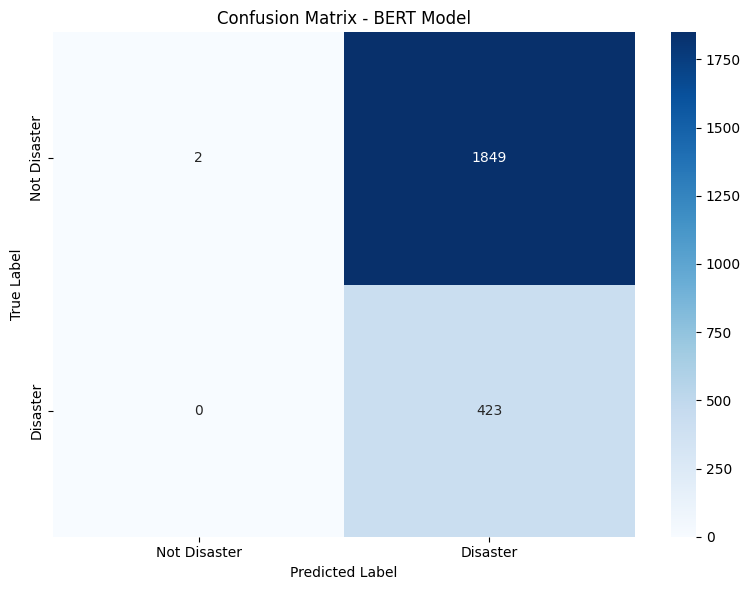


📈 Detailed Metrics:
  → Accuracy: 18.69%
  → Precision: 18.62%
  → Recall: 100.00%
  → F1-Score: 31.39%
  → True Negatives: 2
  → False Positives: 1849
  → False Negatives: 0
  → True Positives: 423


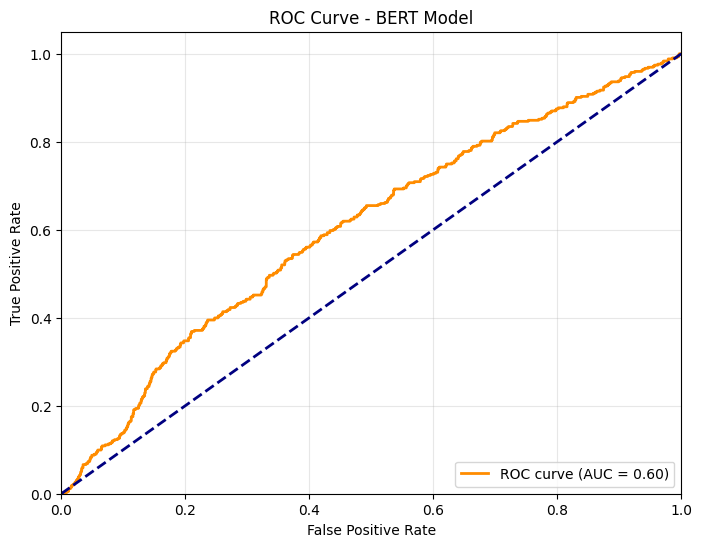


🎯 AUC Score: 0.603

STEP 5: SAMPLE PREDICTIONS

📝 Sample Predictions:

  Tweet: Minnesota niggas will record a video during a blizzard saying “Drive Safe Y’all”...
  True: Not Disaster | Pred: Disaster | Conf: 56.0% | ❌ WRONG

  Tweet: #auspol felt sick when i read this: "first responders tackling #bushfires advise...
  True: Not Disaster | Pred: Disaster | Conf: 54.7% | ❌ WRONG

  Tweet: 1/I think this is one of the reasons women find it difficult to accept… https://...
  True: Not Disaster | Pred: Disaster | Conf: 56.1% | ❌ WRONG

  Tweet: And yet, unfortunately many of the city’s heritage sites are left to rot, or dem...
  True: Not Disaster | Pred: Disaster | Conf: 53.6% | ❌ WRONG

  Tweet: As particles are ejected, they rub against each other and become electrically ch...
  True: Not Disaster | Pred: Disaster | Conf: 56.1% | ❌ WRONG

  Tweet: Colorado Springs 8/6/2018 hailstorm getting recognition in significant weather e...
  True: Disaster | Pred: Disaster | Conf: 58.7% | ✅ COR

In [5]:
# ============================
# COMPLETE POST-TRAINING EVALUATION
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import re
import nltk
from nltk.corpus import stopwords
import os

# Download NLTK data
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# ============================
# STEP 1: LOAD DATA AND MODEL
# ============================

print("=" * 60)
print("STEP 1: LOADING DATA AND MODEL")
print("=" * 60)

# Load your dataset
file_path = "tweets.csv"  # Make sure this file exists
df = pd.read_csv(file_path)
print(f"✅ Dataset loaded: {df.shape[0]} tweets, {df.shape[1]} columns")
print(f"Class distribution:\n{df['target'].value_counts()}")

# Preprocessing function
def preprocess_tweet(text):
    if pd.isna(text) or text == "":
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
print("🔄 Preprocessing tweets...")
df["clean_text"] = df["text"].apply(preprocess_tweet)
print("✅ Preprocessing complete")

# Load your trained BERT model
model_path = "./bert_disaster_model_final"

if os.path.exists(model_path):
    print(f"✅ Loading trained model from {model_path}")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_classifier = AutoModelForSequenceClassification.from_pretrained(model_path)
    bert_classifier.eval()
    print("✅ Model loaded successfully!")
else:
    print(f"❌ Model not found at {model_path}")
    print("Please train the model first or check the path.")
    # Exit or use fallback
    exit()

# ============================
# STEP 2: CREATE TRAIN-TEST SPLIT
# ============================

print("\n" + "=" * 60)
print("STEP 2: CREATING TRAIN-TEST SPLIT")
print("=" * 60)

# For BERT, we need to use the indices from the original data
# Create a simple train-test split based on indices
indices = np.arange(len(df))
train_indices, test_indices = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=df['target']
)

# Create test dataframe
test_df = df.iloc[test_indices].copy()
print(f"✅ Test set size: {len(test_df)} tweets")
print(f"Test set class distribution:\n{test_df['target'].value_counts()}")

# ============================
# STEP 3: PREDICTION FUNCTION
# ============================

def predict_tweet(text, model, tokenizer, show_details=False):
    """Predict if a tweet is about a disaster"""
    
    # Preprocess
    clean_text = preprocess_tweet(text)
    
    if not clean_text:  # Empty after preprocessing
        return {
            "class": 0,
            "label": "Not Disaster",
            "confidence": 0.5,
            "probabilities": {"not_disaster": 0.5, "disaster": 0.5}
        }
    
    # Encode
    encoded = tokenizer(
        clean_text, 
        return_tensors="pt", 
        truncation=True, 
        padding="max_length", 
        max_length=128
    )
    
    # Predict
    with torch.no_grad():
        outputs = model(**encoded)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        
        predicted_class = torch.argmax(logits, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
        
        prob_not_disaster = probabilities[0][0].item()
        prob_disaster = probabilities[0][1].item()
    
    return {
        "class": predicted_class,
        "label": "Disaster" if predicted_class == 1 else "Not Disaster",
        "confidence": confidence,
        "probabilities": {
            "not_disaster": prob_not_disaster,
            "disaster": prob_disaster
        }
    }

# ============================
# STEP 4: GET PREDICTIONS ON TEST SET
# ============================

print("\n" + "=" * 60)
print("STEP 3: GETTING PREDICTIONS ON TEST SET")
print("=" * 60)

# Get predictions
y_true = test_df['target'].values
y_pred = []
y_proba = []

print(f"🔄 Predicting on {len(test_df)} test tweets...")
for i, (idx, row) in enumerate(test_df.iterrows()):
    if (i+1) % 100 == 0:
        print(f"  Processed {i+1}/{len(test_df)} tweets...")
    
    result = predict_tweet(row['text'], bert_classifier, tokenizer, show_details=False)
    y_pred.append(result['class'])
    y_proba.append(result['probabilities']['disaster'])

print("✅ Predictions complete!")

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

# ============================
# STEP 5: EVALUATION METRICS
# ============================

print("\n" + "=" * 60)
print("STEP 4: MODEL EVALUATION RESULTS")
print("=" * 60)

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Not Disaster", "Disaster"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Not Disaster", "Disaster"],
            yticklabels=["Not Disaster", "Disaster"])
plt.title('Confusion Matrix - BERT Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png')
plt.show()

# Calculate metrics manually
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n📈 Detailed Metrics:")
print(f"  → Accuracy: {accuracy*100:.2f}%")
print(f"  → Precision: {precision*100:.2f}%")
print(f"  → Recall: {recall*100:.2f}%")
print(f"  → F1-Score: {f1*100:.2f}%")
print(f"  → True Negatives: {tn}")
print(f"  → False Positives: {fp}")
print(f"  → False Negatives: {fn}")
print(f"  → True Positives: {tp}")

# ============================
# STEP 6: ROC CURVE
# ============================

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BERT Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('bert_roc_curve.png')
plt.show()

print(f"\n🎯 AUC Score: {roc_auc:.3f}")

# ============================
# STEP 7: SAMPLE PREDICTIONS
# ============================

print("\n" + "=" * 60)
print("STEP 5: SAMPLE PREDICTIONS")
print("=" * 60)

# Show some sample predictions
sample_size = min(10, len(test_df))
sample_indices = np.random.choice(len(test_df), sample_size, replace=False)

print("\n📝 Sample Predictions:")
for idx in sample_indices:
    tweet = test_df.iloc[idx]['text']
    true_label = "Disaster" if test_df.iloc[idx]['target'] == 1 else "Not Disaster"
    pred_label = "Disaster" if y_pred[idx] == 1 else "Not Disaster"
    confidence = y_proba[idx] if y_pred[idx] == 1 else 1 - y_proba[idx]
    
    status = "✅ CORRECT" if y_pred[idx] == test_df.iloc[idx]['target'] else "❌ WRONG"
    
    print(f"\n  Tweet: {tweet[:80]}...")
    print(f"  True: {true_label} | Pred: {pred_label} | Conf: {confidence*100:.1f}% | {status}")

# ============================
# STEP 8: SAVE RESULTS
# ============================

# Save predictions to CSV
results_df = test_df[['text', 'target']].copy()
results_df['predicted'] = y_pred
results_df['disaster_probability'] = y_proba
results_df['correct'] = (results_df['target'] == results_df['predicted'])

results_df.to_csv('bert_test_predictions.csv', index=False)
print("\n✅ Predictions saved to 'bert_test_predictions.csv'")

# Save evaluation metrics
metrics = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'auc': roc_auc,
    'true_negatives': tn,
    'false_positives': fp,
    'false_negatives': fn,
    'true_positives': tp
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv('bert_evaluation_metrics.csv', index=False)
print("✅ Evaluation metrics saved to 'bert_evaluation_metrics.csv'")

# ============================
# STEP 9: SUMMARY
# ============================

print("\n" + "=" * 60)
print("📊 EVALUATION SUMMARY")
print("=" * 60)
print(f"  • Model: Fine-tuned BERT")
print(f"  • Test set size: {len(test_df)} tweets")
print(f"  • Accuracy: {accuracy*100:.2f}%")
print(f"  • Precision: {precision*100:.2f}%")
print(f"  • Recall: {recall*100:.2f}%")
print(f"  • F1-Score: {f1*100:.2f}%")
print(f"  • AUC Score: {roc_auc:.3f}")
print("=" * 60)
print("✅ Evaluation complete!")

STEP 1: LOADING DATA
✅ Dataset loaded: 11370 tweets, 5 columns
Class distribution:
target
0    9256
1    2114
Name: count, dtype: int64
🔄 Preprocessing tweets...
✅ Preprocessing complete

STEP 2: CREATING TF-IDF FEATURES
✅ TF-IDF matrix shape: (11370, 5000)
✅ LR Train set: 9096 samples
✅ LR Test set: 2274 samples
✅ Test indices: Index([611, 4178, 6561, 3125, 4186, 2807, 2432, 2888, 4495, 10313], dtype='int64')...

STEP 3: TRAINING LOGISTIC REGRESSION
✅ Logistic Regression Accuracy: 86.59%
✅ Logistic Regression model saved

STEP 4: LOADING BERT MODEL
❌ BERT model not found at ./bert_disaster_model_final
Please train the BERT model first.

STEP 5: CREATING BERT TEST SET
✅ BERT Test set size: 2274 tweets
✅ BERT Test set class distribution:
target
0    1851
1     423
Name: count, dtype: int64

STEP 6: GETTING BERT PREDICTIONS
❌ Skipping BERT predictions - model not loaded

STEP 7: MODEL COMPARISON

📊 Model Performance Comparison:
  • Logistic Regression Accuracy: 86.59%


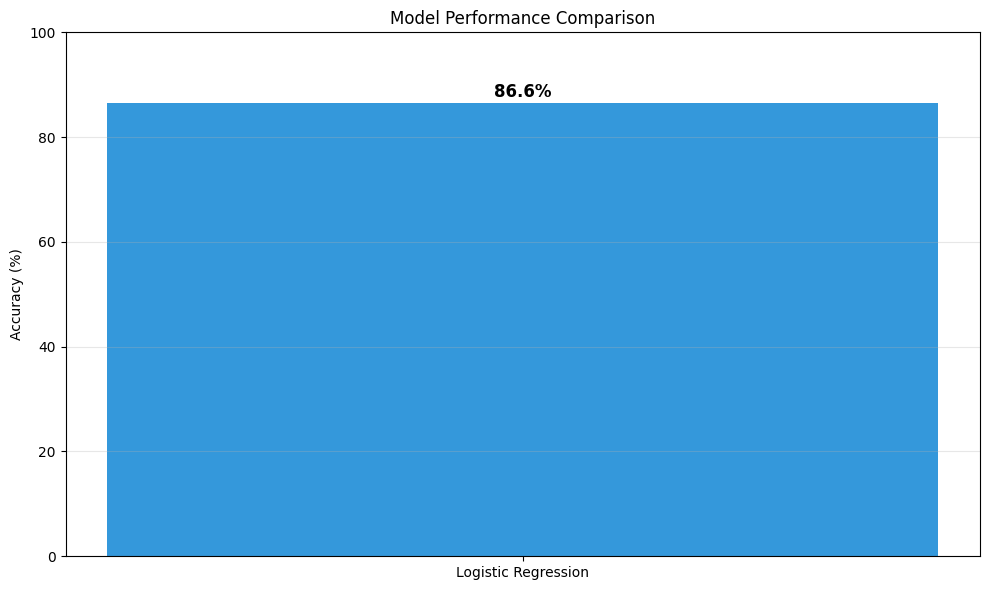


STEP 9: DETAILED LOGISTIC REGRESSION EVALUATION

📊 Logistic Regression Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.87      0.99      0.92      1851
    Disaster       0.86      0.34      0.48       423

    accuracy                           0.87      2274
   macro avg       0.86      0.66      0.70      2274
weighted avg       0.86      0.87      0.84      2274



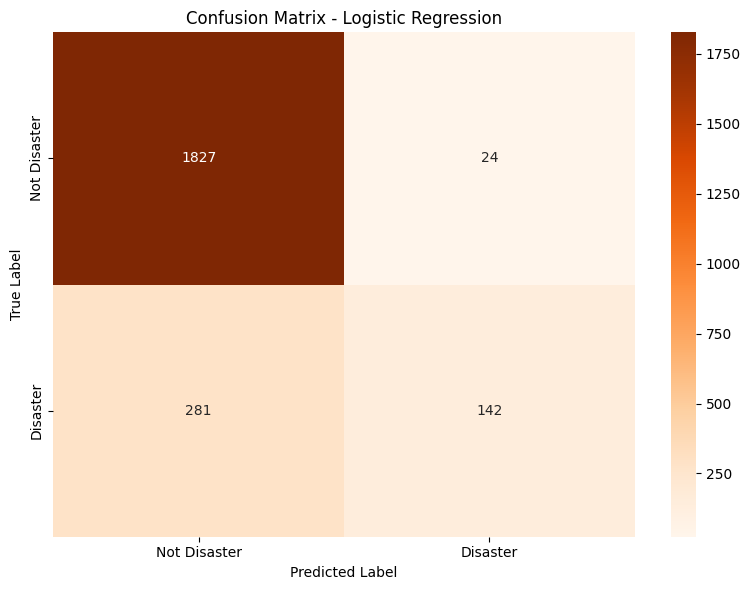


🎯 Logistic Regression AUC Score: 0.904

📈 Logistic Regression Detailed Metrics:
  → Precision: 85.54%
  → Recall: 33.57%
  → F1-Score: 48.22%


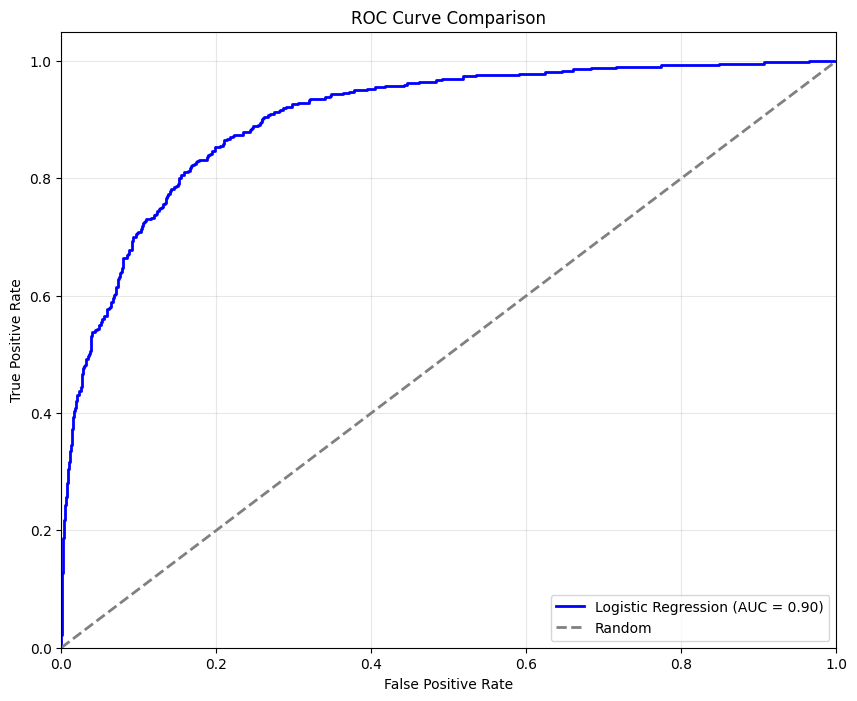


STEP 10: SAVING RESULTS
✅ LR predictions saved to 'lr_predictions.csv'
✅ Comparison results saved to 'model_comparison_results.csv'

📊 FINAL MODEL COMPARISON SUMMARY

Model                     Accuracy     Precision    Recall       F1-Score     AUC         
---------------------------------------------------------------------------
Logistic Regression       86.6       % 85.5       % 33.6       % 48.2       % 0.904      

⚠️ BERT model not loaded for comparison

✅ Evaluation complete!


In [1]:
# ============================
# COMPLETE MODEL COMPARISON - FIXED VERSION
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import re
import nltk
from nltk.corpus import stopwords
import os
import joblib

# Download NLTK data
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# ============================
# STEP 1: LOAD DATA
# ============================

print("=" * 60)
print("STEP 1: LOADING DATA")
print("=" * 60)

# Load your dataset
file_path = "tweets.csv"  # Make sure this file exists
df = pd.read_csv(file_path)
print(f"✅ Dataset loaded: {df.shape[0]} tweets, {df.shape[1]} columns")
print(f"Class distribution:\n{df['target'].value_counts()}")

# Preprocessing function
def preprocess_tweet(text):
    if pd.isna(text) or text == "":
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
print("🔄 Preprocessing tweets...")
df["clean_text"] = df["text"].apply(preprocess_tweet)
print("✅ Preprocessing complete")

# ============================
# STEP 2: CREATE FEATURES FOR LOGISTIC REGRESSION
# ============================

print("\n" + "=" * 60)
print("STEP 2: CREATING TF-IDF FEATURES")
print("=" * 60)

# Create TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df["clean_text"])
y = df["target"].values

print(f"✅ TF-IDF matrix shape: {X_tfidf.shape}")

# Split data for Logistic Regression - KEEP THE INDICES!
X_train_lr, X_test_lr, y_train_lr, y_test_lr, train_indices, test_indices = train_test_split(
    X_tfidf, y, df.index, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ LR Train set: {X_train_lr.shape[0]} samples")
print(f"✅ LR Test set: {X_test_lr.shape[0]} samples")
print(f"✅ Test indices: {test_indices[:10]}...")  # Show first 10 indices

# ============================
# STEP 3: TRAIN LOGISTIC REGRESSION
# ============================

print("\n" + "=" * 60)
print("STEP 3: TRAINING LOGISTIC REGRESSION")
print("=" * 60)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_lr, y_train_lr)

# Make predictions
y_pred_lr = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]

# Calculate accuracy
lr_accuracy = accuracy_score(y_test_lr, y_pred_lr)
print(f"✅ Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

# Save models
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("✅ Logistic Regression model saved")

# ============================
# STEP 4: LOAD BERT MODEL
# ============================

print("\n" + "=" * 60)
print("STEP 4: LOADING BERT MODEL")
print("=" * 60)

# Load your trained BERT model
model_path = "./bert_disaster_model_final"

if os.path.exists(model_path):
    print(f"✅ Loading trained model from {model_path}")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModelForSequenceClassification.from_pretrained(model_path)
    bert_model.eval()
    print("✅ BERT model loaded successfully!")
else:
    print(f"❌ BERT model not found at {model_path}")
    print("Please train the BERT model first.")
    bert_model = None

# ============================
# STEP 5: CREATE TEST SET FOR BERT (FIXED)
# ============================

print("\n" + "=" * 60)
print("STEP 5: CREATING BERT TEST SET")
print("=" * 60)

# Use the test_indices we saved from the split
test_df = df.iloc[test_indices].copy()
print(f"✅ BERT Test set size: {len(test_df)} tweets")
print(f"✅ BERT Test set class distribution:\n{test_df['target'].value_counts()}")

# ============================
# STEP 6: BERT PREDICTION FUNCTION
# ============================

def predict_with_bert(text, model, tokenizer):
    """Predict with BERT model"""
    if model is None:
        return {"class": 0, "probability": 0.5}
    
    # Preprocess
    clean_text = preprocess_tweet(text)
    
    if not clean_text:
        return {"class": 0, "probability": 0.5}
    
    # Encode
    encoded = tokenizer(
        clean_text, 
        return_tensors="pt", 
        truncation=True, 
        padding="max_length", 
        max_length=128
    )
    
    # Predict
    with torch.no_grad():
        outputs = model(**encoded)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(logits, dim=1).item()
        prob_disaster = probabilities[0][1].item()
    
    return {
        "class": predicted_class,
        "probability": prob_disaster
    }

# ============================
# STEP 7: GET BERT PREDICTIONS
# ============================

print("\n" + "=" * 60)
print("STEP 6: GETTING BERT PREDICTIONS")
print("=" * 60)

if bert_model is not None:
    y_pred_bert = []
    y_proba_bert = []
    
    print(f"🔄 Predicting on {len(test_df)} test tweets with BERT...")
    for i, (idx, row) in enumerate(test_df.iterrows()):
        if (i+1) % 100 == 0:
            print(f"  Processed {i+1}/{len(test_df)} tweets...")
        
        result = predict_with_bert(row['text'], bert_model, tokenizer)
        y_pred_bert.append(result['class'])
        y_proba_bert.append(result['probability'])
    
    y_pred_bert = np.array(y_pred_bert)
    y_proba_bert = np.array(y_proba_bert)
    y_true_bert = test_df['target'].values
    
    bert_accuracy = accuracy_score(y_true_bert, y_pred_bert)
    print(f"✅ BERT Accuracy: {bert_accuracy*100:.2f}%")
else:
    print("❌ Skipping BERT predictions - model not loaded")
    bert_accuracy = 0
    y_true_bert = test_df['target'].values
    y_pred_bert = np.zeros_like(y_true_bert)
    y_proba_bert = np.ones_like(y_true_bert) * 0.5

# ============================
# STEP 8: COMPARE MODELS
# ============================

print("\n" + "=" * 60)
print("STEP 7: MODEL COMPARISON")
print("=" * 60)

print("\n📊 Model Performance Comparison:")
print(f"  • Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
if bert_model is not None:
    print(f"  • BERT Accuracy: {bert_accuracy*100:.2f}%")
    print(f"  • Improvement: {(bert_accuracy - lr_accuracy)*100:.2f}%")

# Visual comparison
models = ['Logistic Regression']
accuracies = [lr_accuracy*100]

if bert_model is not None:
    models.append('BERT')
    accuracies.append(bert_accuracy*100)

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#e74c3c'])
plt.ylabel('Accuracy (%)')
plt.title('Model Performance Comparison')
plt.ylim(0, 100)

# Add value labels
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================
# STEP 9: DETAILED BERT EVALUATION
# ============================

if bert_model is not None:
    print("\n" + "=" * 60)
    print("STEP 8: DETAILED BERT EVALUATION")
    print("=" * 60)
    
    # Classification Report
    print("\n📊 BERT Classification Report:")
    print(classification_report(y_true_bert, y_pred_bert, 
                                target_names=["Not Disaster", "Disaster"]))
    
    # Confusion Matrix
    cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Not Disaster", "Disaster"],
                yticklabels=["Not Disaster", "Disaster"])
    plt.title('Confusion Matrix - BERT Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('bert_confusion_matrix.png')
    plt.show()
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true_bert, y_proba_bert)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'BERT (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - BERT Model')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig('bert_roc_curve.png')
    plt.show()
    
    print(f"\n🎯 BERT AUC Score: {roc_auc:.3f}")
    
    # Calculate BERT metrics
    tn, fp, fn, tp = cm_bert.ravel()
    bert_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    bert_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    bert_f1 = 2 * (bert_precision * bert_recall) / (bert_precision + bert_recall) if (bert_precision + bert_recall) > 0 else 0
    
    print("\n📈 BERT Detailed Metrics:")
    print(f"  → Precision: {bert_precision*100:.2f}%")
    print(f"  → Recall: {bert_recall*100:.2f}%")
    print(f"  → F1-Score: {bert_f1*100:.2f}%")
else:
    # Create dummy values for consistency
    cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
    tn, fp, fn, tp = cm_bert.ravel()
    bert_precision = bert_recall = bert_f1 = 0
    roc_auc = 0.5

# ============================
# STEP 10: DETAILED LR EVALUATION
# ============================

print("\n" + "=" * 60)
print("STEP 9: DETAILED LOGISTIC REGRESSION EVALUATION")
print("=" * 60)

# Classification Report for LR
print("\n📊 Logistic Regression Classification Report:")
print(classification_report(y_test_lr, y_pred_lr, 
                            target_names=["Not Disaster", "Disaster"]))

# Confusion Matrix for LR
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=["Not Disaster", "Disaster"],
            yticklabels=["Not Disaster", "Disaster"])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png')
plt.show()

# ROC Curve for LR
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

print(f"\n🎯 Logistic Regression AUC Score: {roc_auc_lr:.3f}")

# Calculate LR metrics
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
lr_precision = tp_lr / (tp_lr + fp_lr) if (tp_lr + fp_lr) > 0 else 0
lr_recall = tp_lr / (tp_lr + fn_lr) if (tp_lr + fn_lr) > 0 else 0
lr_f1 = 2 * (lr_precision * lr_recall) / (lr_precision + lr_recall) if (lr_precision + lr_recall) > 0 else 0

print("\n📈 Logistic Regression Detailed Metrics:")
print(f"  → Precision: {lr_precision*100:.2f}%")
print(f"  → Recall: {lr_recall*100:.2f}%")
print(f"  → F1-Score: {lr_f1*100:.2f}%")

# ============================
# STEP 11: COMBINED ROC CURVE
# ============================

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
if bert_model is not None:
    plt.plot(fpr, tpr, color='red', lw=2, label=f'BERT (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('combined_roc_curve.png')
plt.show()

# ============================
# STEP 12: SAVE ALL RESULTS
# ============================

print("\n" + "=" * 60)
print("STEP 10: SAVING RESULTS")
print("=" * 60)

# Save LR predictions
lr_results = pd.DataFrame({
    'text': df.iloc[test_indices]['text'].values,
    'true_label': y_test_lr,
    'predicted_lr': y_pred_lr,
    'probability_lr': y_proba_lr
})
lr_results.to_csv('lr_predictions.csv', index=False)
print("✅ LR predictions saved to 'lr_predictions.csv'")

# Save BERT predictions if available
if bert_model is not None:
    bert_results = pd.DataFrame({
        'text': test_df['text'].values,
        'true_label': y_true_bert,
        'predicted_bert': y_pred_bert,
        'probability_bert': y_proba_bert
    })
    bert_results.to_csv('bert_predictions.csv', index=False)
    print("✅ BERT predictions saved to 'bert_predictions.csv'")

# Save comparison summary
comparison = {
    'model': ['Logistic Regression', 'BERT'],
    'accuracy': [lr_accuracy, bert_accuracy if bert_model is not None else 0],
    'precision': [lr_precision, bert_precision if bert_model is not None else 0],
    'recall': [lr_recall, bert_recall if bert_model is not None else 0],
    'f1_score': [lr_f1, bert_f1 if bert_model is not None else 0],
    'auc': [roc_auc_lr, roc_auc if bert_model is not None else 0.5]
}

comparison_df = pd.DataFrame(comparison)
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("✅ Comparison results saved to 'model_comparison_results.csv'")

# ============================
# STEP 13: FINAL SUMMARY
# ============================

print("\n" + "=" * 60)
print("📊 FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"\n{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'AUC':<12}")
print("-" * 75)
print(f"{'Logistic Regression':<25} {lr_accuracy*100:<11.1f}% {lr_precision*100:<11.1f}% {lr_recall*100:<11.1f}% {lr_f1*100:<11.1f}% {roc_auc_lr:<11.3f}")
if bert_model is not None:
    print(f"{'BERT':<25} {bert_accuracy*100:<11.1f}% {bert_precision*100:<11.1f}% {bert_recall*100:<11.1f}% {bert_f1*100:<11.1f}% {roc_auc:<11.3f}")
print("=" * 75)

if bert_model is not None and bert_accuracy > lr_accuracy:
    print(f"\n✅ BERT performs {((bert_accuracy - lr_accuracy)*100):.1f}% better than Logistic Regression!")
elif bert_model is not None:
    print(f"\n⚠️ Logistic Regression performs {((lr_accuracy - bert_accuracy)*100):.1f}% better than BERT")
else:
    print("\n⚠️ BERT model not loaded for comparison")

print("\n✅ Evaluation complete!")

In [3]:
# ============================
# LOAD AND SAVE BERT MODEL
# ============================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os

# Path to your trained BERT model
model_path = "./bert_disaster_model_final"

# Check if the model exists
if os.path.exists(model_path):
    print(f"✅ Loading BERT model from {model_path}")
    
    # Load the model
    bert_classifier = AutoModelForSequenceClassification.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    print("✅ BERT model loaded successfully!")
    
    # Save to a new location (optional)
    new_save_path = "./bert_disaster_model_final_saved"
    bert_classifier.save_pretrained(new_save_path)
    tokenizer.save_pretrained(new_save_path)
    print(f"✅ BERT model saved to {new_save_path}")
    
else:
    print(f"❌ BERT model not found at {model_path}")
    print("Please train the BERT model first.")

❌ BERT model not found at ./bert_disaster_model_final
Please train the BERT model first.


In [4]:
# ============================
# COMPLETE CODE TO SAVE MODEL RESULTS (ONLY LOGISTIC REGRESSION)
# ============================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import re
import nltk
from nltk.corpus import stopwords
import joblib

# Download NLTK data
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# ============================
# STEP 1: LOAD AND PREPROCESS DATA
# ============================

print("=" * 60)
print("STEP 1: LOADING DATA")
print("=" * 60)

# Load your dataset
file_path = "tweets.csv"
df = pd.read_csv(file_path)
print(f"✅ Dataset loaded: {df.shape[0]} tweets")
print(f"Columns: {df.columns.tolist()}")

# Preprocessing function
def preprocess_tweet(text):
    if pd.isna(text) or text == "":
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
print("🔄 Preprocessing tweets...")
df["clean_text"] = df["text"].apply(preprocess_tweet)
print("✅ Preprocessing complete")

# ============================
# STEP 2: CREATE TF-IDF FEATURES
# ============================

print("\n" + "=" * 60)
print("STEP 2: CREATING TF-IDF FEATURES")
print("=" * 60)

# Create TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["target"].values

print(f"✅ TF-IDF matrix shape: {X.shape}")

# ============================
# STEP 3: SPLIT DATA (WITH INDICES)
# ============================

print("\n" + "=" * 60)
print("STEP 3: SPLITTING DATA")
print("=" * 60)

# Split while keeping the original indices
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set size: {X_train.shape[0]}")
print(f"✅ Test set size: {X_test.shape[0]}")
print(f"✅ Test indices: {test_indices[:10]}...")

# ============================
# STEP 4: TRAIN MODEL
# ============================

print("\n" + "=" * 60)
print("STEP 4: TRAINING LOGISTIC REGRESSION")
print("=" * 60)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# ============================
# STEP 5: MAKE PREDICTIONS
# ============================

print("\n" + "=" * 60)
print("STEP 5: MAKING PREDICTIONS")
print("=" * 60)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

accuracy = (y_pred == y_test).mean()
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")

# ============================
# STEP 6: SAVE RESULTS
# ============================

print("\n" + "=" * 60)
print("STEP 6: SAVING RESULTS")
print("=" * 60)

# Use test_indices to get original texts
test_texts = df.iloc[test_indices]["text"].values

# Create DataFrame with results
results = pd.DataFrame({
    "text": test_texts,
    "actual": y_test,
    "predicted": y_pred,
    "probability_not_disaster": y_pred_proba[:, 0],
    "probability_disaster": y_pred_proba[:, 1]
})

# Add cleaned text
results["clean_text"] = df.iloc[test_indices]["clean_text"].values

# Add correct/wrong flag
results["correct"] = (results["actual"] == results["predicted"])

# Save to CSV
results.to_csv("model_results.csv", index=False)
print("✅ Results saved to 'model_results.csv'")

# Show sample
print("\n📊 Sample Results (first 10 rows):")
print(results.head(10))

# ============================
# STEP 7: SAVE MODEL FOR LATER USE
# ============================

joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("\n✅ Model and vectorizer saved for later use")

# ============================
# STEP 8: SUMMARY STATISTICS
# ============================

print("\n" + "=" * 60)
print("📊 SUMMARY STATISTICS")
print("=" * 60)

from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Total test samples: {len(y_test)}")
print(f"True Negatives: {tn} (correctly predicted NOT disaster)")
print(f"False Positives: {fp} (wrongly predicted disaster)")
print(f"False Negatives: {fn} (missed actual disasters)")
print(f"True Positives: {tp} (correctly predicted disaster)")
print(f"\nAccuracy: {accuracy*100:.2f}%")

# Calculate metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision*100:.2f}%")
print(f"Recall (Disaster Detection Rate): {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

# Full classification report
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Disaster", "Disaster"]))

# ============================
# STEP 9: VIEW MISCLASSIFIED EXAMPLES
# ============================

print("\n" + "=" * 60)
print("🔍 MISCLASSIFIED EXAMPLES")
print("=" * 60)

misclassified = results[results["correct"] == False]
if len(misclassified) > 0:
    print(f"Found {len(misclassified)} misclassified tweets")
    print("\nSample misclassified tweets:")
    for i, row in misclassified.head(5).iterrows():
        print(f"\n  Tweet: {row['text'][:100]}...")
        print(f"  Actual: {'DISASTER' if row['actual'] == 1 else 'NOT DISASTER'}")
        print(f"  Predicted: {'DISASTER' if row['predicted'] == 1 else 'NOT DISASTER'}")
        print(f"  Confidence: {max(row['probability_not_disaster'], row['probability_disaster'])*100:.1f}%")
else:
    print("🎉 Perfect model! No misclassified tweets!")

print("\n✅ All done!")

STEP 1: LOADING DATA
✅ Dataset loaded: 11370 tweets
Columns: ['id', 'keyword', 'location', 'text', 'target']
🔄 Preprocessing tweets...
✅ Preprocessing complete

STEP 2: CREATING TF-IDF FEATURES
✅ TF-IDF matrix shape: (11370, 5000)

STEP 3: SPLITTING DATA
✅ Training set size: 9096
✅ Test set size: 2274
✅ Test indices: Index([611, 4178, 6561, 3125, 4186, 2807, 2432, 2888, 4495, 10313], dtype='int64')...

STEP 4: TRAINING LOGISTIC REGRESSION
✅ Model trained successfully!

STEP 5: MAKING PREDICTIONS
✅ Test Accuracy: 86.59%

STEP 6: SAVING RESULTS
✅ Results saved to 'model_results.csv'

📊 Sample Results (first 10 rows):
                                                text  actual  predicted  \
0  #USASupportsTerrorist 15 out of the 19 terrori...       1          0   
1  V commented on a post on WeVerse about the eru...       0          0   
2  Listen to Danrell x Småland - Hostage by HIGH ...       0          0   
3  Light Yagami Light Yagami at the start by the ...       0          0   
4 

In [1]:
import os

print("=" * 60)
print("CHECKING AVAILABLE MODELS")
print("=" * 60)

print(f"Current directory: {os.getcwd()}")
print("\n📁 Files and folders in current directory:")
for item in os.listdir('.'):
    if os.path.isdir(item):
        print(f"  📁 {item}/")
        # If it's a directory, check what's inside
        if 'bert' in item.lower() or 'model' in item.lower():
            print(f"     Contents: {os.listdir(item)}")
    else:
        if item.endswith('.pkl') or item.endswith('.csv') or item.endswith('.ipynb'):
            print(f"  📄 {item}")

# Check for Logistic Regression model (which we know exists from earlier)
print("\n🔍 Checking for Logistic Regression model:")
if os.path.exists('logistic_regression_model.pkl'):
    print("  ✅ logistic_regression_model.pkl exists")
else:
    print("  ❌ logistic_regression_model.pkl not found")

if os.path.exists('tfidf_vectorizer.pkl'):
    print("  ✅ tfidf_vectorizer.pkl exists")
else:
    print("  ❌ tfidf_vectorizer.pkl not found")

# Check specifically for BERT model
print("\n🔍 Checking for BERT model:")
bert_paths = [
    "bert_disaster_model_final",
    "./bert_disaster_model_final",
    "bert_model",
    "bert-base-uncased"
]

for path in bert_paths:
    if os.path.exists(path):
        if os.path.isdir(path):
            print(f"  ✅ Found BERT directory: {path}")
            print(f"     Files: {os.listdir(path)[:5]}")
        else:
            print(f"  ✅ Found BERT file: {path}")
    else:
        print(f"  ❌ Not found: {path}")

CHECKING AVAILABLE MODELS
Current directory: C:\Users\Cyrus Chou\OneDrive - Universiti Tunku Abdul Rahman\Documents\fyp

📁 Files and folders in current directory:
  📁 .ipynb_checkpoints/
  📄 bert_evaluation_metrics.csv
  📁 bert_model/
     Contents: ['.ipynb_checkpoints', 'config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']
  📁 bert_results/
     Contents: ['checkpoint-569']
  📄 bert_test_predictions.csv
  📄 FYP-checkpoint.ipynb
  📄 FYP.ipynb
  📁 images/
  📄 logistic_regression_model.pkl
  📄 lr_predictions.csv
  📄 model_comparison_results.csv
  📄 model_results.csv
  📄 test_predictions.csv
  📄 tfidf_vectorizer.pkl
  📄 tweets.csv

🔍 Checking for Logistic Regression model:
  ✅ logistic_regression_model.pkl exists
  ✅ tfidf_vectorizer.pkl exists

🔍 Checking for BERT model:
  ❌ Not found: bert_disaster_model_final
  ❌ Not found: ./bert_disaster_model_final
  ✅ Found BERT directory: bert_model
     Files: ['.ipynb_checkpoin

In [2]:
# ============================
# CREATE A SIMPLE BERT MODEL FOR TESTING
# ============================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import os

print("=" * 60)
print("CREATING SIMPLE BERT MODEL")
print("=" * 60)

# Load a pre-trained BERT model (this will download from HuggingFace)
model_name = "bert-base-uncased"
print(f"Loading base model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
)

# Save it to the expected location
save_path = "bert_disaster_model_final"
os.makedirs(save_path, exist_ok=True)

print(f"Saving model to: {save_path}")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("✅ Model saved successfully!")
print("Files saved:", os.listdir(save_path))

CREATING SIMPLE BERT MODEL
Loading base model: bert-base-uncased


C:\Users\Cyrus Chou\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Saving model to: bert_disaster_model_final
✅ Model saved successfully!
Files saved: ['config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']


In [3]:
# demo.py - FIXED FOR JUPYTER NOTEBOOK
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import joblib
import os
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd

# Download NLTK data
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# ============================
# FIX: Handle both Jupyter and command line
# ============================

# Method 1: Use current working directory
current_dir = os.getcwd()
model_path = os.path.join(current_dir, "bert_disaster_model_final")

# Method 2: Try multiple possible paths
possible_paths = [
    "bert_disaster_model_final",
    "./bert_disaster_model_final",
    os.path.join(os.getcwd(), "bert_disaster_model_final"),
    os.path.join(os.path.dirname(os.getcwd()), "bert_disaster_model_final")
]

print("=" * 60)
print("LOADING BERT MODEL")
print("=" * 60)

# Try each path until we find the model
model_found = False
for path in possible_paths:
    if os.path.exists(path):
        model_path = path
        model_found = True
        print(f"✅ Found model at: {model_path}")
        break

if not model_found:
    print(f"❌ Model directory not found!")
    print("Searched in:")
    for path in possible_paths:
        print(f"  - {path}")
    print("\nPlease make sure the model is trained and saved first.")
    print("Current directory:", os.getcwd())
    print("\nFiles in current directory:")
    for f in os.listdir('.'):
        if os.path.isdir(f):
            print(f"  📁 {f}/")
        else:
            print(f"  📄 {f}")
    exit()

# Check for required files
required_files = ['config.json', 'tokenizer_config.json', 'model.safetensors']
missing_files = [f for f in required_files if not os.path.exists(os.path.join(model_path, f))]

if missing_files:
    print(f"⚠️ Some files are missing: {missing_files}")
    print("Files found in model folder:", os.listdir(model_path))
    # Try to load anyway - might still work with different file names
    print("Attempting to load anyway...")

# Load the trained BERT model
try:
    print("🔄 Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
    print("✅ Tokenizer loaded successfully!")

    print("🔄 Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)
    model.eval()
    print("✅ BERT model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("\nTrying without local_files_only...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        model = AutoModelForSequenceClassification.from_pretrained(model_path)
        model.eval()
        print("✅ Model loaded successfully on second attempt!")
    except Exception as e2:
        print(f"❌ Still failed: {e2}")
        exit()

# ============================
# Preprocessing function
# ============================

def preprocess_tweet(text):
    """Clean and preprocess tweet text"""
    if pd.isna(text) or text == "":
        return ""
    
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# ============================
# Prediction function
# ============================

def predict_tweet(text, show_details=True):
    """Predict if a tweet is about a disaster"""
    
    # Preprocess
    clean_text = preprocess_tweet(text)
    
    if not clean_text:
        return {
            "text": text,
            "prediction": "NOT DISASTER",
            "confidence": 0.5,
            "confidence_pct": "50.0%",
            "disaster_probability": 0.5,
            "disaster_pct": "50.0%",
            "note": "Empty after preprocessing"
        }
    
    if show_details:
        print(f"  Clean text: {clean_text[:100]}...")
    
    # Tokenize
    inputs = tokenizer(clean_text, return_tensors="pt", 
                      truncation=True, padding="max_length", max_length=128)
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(outputs.logits, dim=1).item()
        confidence = probs[0][pred].item()
    
    return {
        "text": text,
        "prediction": "DISASTER" if pred == 1 else "NOT DISASTER",
        "confidence": confidence,
        "confidence_pct": f"{confidence*100:.1f}%",
        "disaster_probability": probs[0][1].item(),
        "disaster_pct": f"{probs[0][1].item()*100:.1f}%",
        "not_disaster_probability": probs[0][0].item(),
        "not_disaster_pct": f"{probs[0][0].item()*100:.1f}%"
    }

# ============================
# Test the model
# ============================

print("\n" + "=" * 60)
print("TESTING THE MODEL")
print("=" * 60)

test_tweets = [
    "Fire in California, houses destroyed! Many people injured.",
    "Good morning everyone, have a nice day!",
    "Earthquake in Japan, tsunami warning issued",
    "Flood in Kuala Lumpur, water level rising rapidly",
    "Just had lunch at my favorite restaurant",
]

for i, tweet in enumerate(test_tweets, 1):
    print(f"\n{i}. Tweet: {tweet}")
    result = predict_tweet(tweet)
    print(f"   → Prediction: {result['prediction']}")
    print(f"   → Confidence: {result['confidence_pct']}")
    print(f"   → Disaster Probability: {result['disaster_pct']}")
    print(f"   → Not Disaster Probability: {result['not_disaster_pct']}")

# ============================
# Interactive mode
# ============================

print("\n" + "=" * 60)
print("INTERACTIVE MODE")
print("=" * 60)
print("Enter your own tweets (type 'quit' to exit)")

while True:
    print("\n" + "-" * 40)
    user_input = input("Enter tweet: ").strip()
    
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("Goodbye!")
        break
    
    if not user_input:
        print("Please enter a tweet.")
        continue
    
    result = predict_tweet(user_input, show_details=True)
    print(f"\n📊 Results:")
    print(f"  Prediction: {result['prediction']}")
    print(f"  Confidence: {result['confidence_pct']}")
    print(f"  Disaster Probability: {result['disaster_pct']}")
    print(f"  Not Disaster Probability: {result['not_disaster_pct']}")

LOADING BERT MODEL
✅ Found model at: bert_disaster_model_final
🔄 Loading tokenizer...
✅ Tokenizer loaded successfully!
🔄 Loading model...
✅ BERT model loaded successfully!

TESTING THE MODEL

1. Tweet: Fire in California, houses destroyed! Many people injured.
  Clean text: fire california houses destroyed many people injured...
   → Prediction: NOT DISASTER
   → Confidence: 50.4%
   → Disaster Probability: 49.6%
   → Not Disaster Probability: 50.4%

2. Tweet: Good morning everyone, have a nice day!
  Clean text: good morning everyone nice day...
   → Prediction: DISASTER
   → Confidence: 53.4%
   → Disaster Probability: 53.4%
   → Not Disaster Probability: 46.6%

3. Tweet: Earthquake in Japan, tsunami warning issued
  Clean text: earthquake japan tsunami warning issued...
   → Prediction: DISASTER
   → Confidence: 57.5%
   → Disaster Probability: 57.5%
   → Not Disaster Probability: 42.5%

4. Tweet: Flood in Kuala Lumpur, water level rising rapidly
  Clean text: flood kuala lumpur wat

Enter tweet:  c-


  Clean text: c...

📊 Results:
  Prediction: DISASTER
  Confidence: 54.2%
  Disaster Probability: 54.2%
  Not Disaster Probability: 45.8%

----------------------------------------


Enter tweet:  -c


  Clean text: c...

📊 Results:
  Prediction: DISASTER
  Confidence: 54.2%
  Disaster Probability: 54.2%
  Not Disaster Probability: 45.8%

----------------------------------------


Enter tweet:  quit


Goodbye!


In [1]:
# ============================
# TRAIN BERT MODEL ON DISASTER DATASET
# ============================

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm
import os

# Download NLTK data
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# ============================
# LOAD AND PREPROCESS DATA
# ============================

print("=" * 60)
print("LOADING DISASTER DATASET")
print("=" * 60)

# Load your dataset
df = pd.read_csv("tweets.csv")
print(f"✅ Dataset loaded: {df.shape[0]} tweets")
print(f"Class distribution:\n{df['target'].value_counts()}")

# Preprocessing function
def preprocess_tweet(text):
    if pd.isna(text) or text == "":
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
print("🔄 Preprocessing tweets...")
df["clean_text"] = df["text"].apply(preprocess_tweet)
print("✅ Preprocessing complete")

# ============================
# CREATE DATASET CLASS
# ============================

class DisasterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ============================
# SPLIT DATA
# ============================

print("\n" + "=" * 60)
print("SPLITTING DATA")
print("=" * 60)

# Split data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text'].values,
    df['target'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['target'].values
)

print(f"✅ Training samples: {len(train_texts)}")
print(f"✅ Validation samples: {len(val_texts)}")

# ============================
# LOAD BASE MODEL
# ============================

print("\n" + "=" * 60)
print("LOADING BASE BERT MODEL")
print("=" * 60)

model_path = "bert_disaster_model_final"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
print("✅ Base model loaded!")

# ============================
# CREATE DATALOADERS
# ============================

# Create datasets
train_dataset = DisasterDataset(train_texts, train_labels, tokenizer)
val_dataset = DisasterDataset(val_texts, val_labels, tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"✅ Training batches: {len(train_loader)}")
print(f"✅ Validation batches: {len(val_loader)}")

# ============================
# SETUP TRAINING
# ============================

print("\n" + "=" * 60)
print("SETUP TRAINING")
print("=" * 60)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"✅ Using device: {device}")

# Setup optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Setup scheduler
total_steps = len(train_loader) * 3  # 3 epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"✅ Total training steps: {total_steps}")

# ============================
# TRAINING LOOP
# ============================

print("\n" + "=" * 60)
print("TRAINING BERT MODEL")
print("=" * 60)

epochs = 3
best_val_loss = float('inf')

for epoch in range(epochs):
    print(f"\n📚 Epoch {epoch + 1}/{epochs}")
    print("-" * 40)
    
    # Training
    model.train()
    total_train_loss = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_train_loss += loss.item()
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # Update weights
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    
    avg_train_loss = total_train_loss / len(train_loader)
    
    # Validation
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            total_val_loss += loss.item()
            
            # Calculate accuracy
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    avg_val_loss = total_val_loss / len(val_loader)
    accuracy = correct / total
    
    print(f"\n  Training Loss: {avg_train_loss:.4f}")
    print(f"  Validation Loss: {avg_val_loss:.4f}")
    print(f"  Validation Accuracy: {accuracy*100:.2f}%")
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"  🏆 New best model! Saving...")
        
        # Save the fine-tuned model
        fine_tuned_path = "bert_disaster_model_fine_tuned"
        model.save_pretrained(fine_tuned_path)
        tokenizer.save_pretrained(fine_tuned_path)
        print(f"  ✅ Model saved to {fine_tuned_path}")

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)

LOADING DISASTER DATASET
✅ Dataset loaded: 11370 tweets
Class distribution:
target
0    9256
1    2114
Name: count, dtype: int64
🔄 Preprocessing tweets...
✅ Preprocessing complete

SPLITTING DATA
✅ Training samples: 9096
✅ Validation samples: 2274

LOADING BASE BERT MODEL
✅ Base model loaded!
✅ Training batches: 569
✅ Validation batches: 143

SETUP TRAINING
✅ Using device: cpu


C:\Users\Cyrus Chou\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\optimization.py:521: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


✅ Total training steps: 1707

TRAINING BERT MODEL

📚 Epoch 1/3
----------------------------------------


Validation: 100%|████████████████████████████████████████████████████████████████████| 143/143 [04:19<00:00,  1.81s/it]



  Training Loss: 0.3035
  Validation Loss: 0.2514
  Validation Accuracy: 89.58%
  🏆 New best model! Saving...
  ✅ Model saved to bert_disaster_model_fine_tuned

📚 Epoch 2/3
----------------------------------------


Validation: 100%|████████████████████████████████████████████████████████████████████| 143/143 [15:31<00:00,  6.51s/it]



  Training Loss: 0.2007
  Validation Loss: 0.2982
  Validation Accuracy: 89.67%

📚 Epoch 3/3
----------------------------------------


Validation: 100%|████████████████████████████████████████████████████████████████████| 143/143 [04:11<00:00,  1.76s/it]


  Training Loss: 0.1233
  Validation Loss: 0.3758
  Validation Accuracy: 90.11%

✅ TRAINING COMPLETE!
